# Проект: Прогнозирование стоимости недвижимости
## Этап 1. Исследование данных (EDA) и Этап 2. Предварительная обработка данных

**Цель исследования:**
На основе характеристик объектов недвижимости провести комплексный исследовательский анализ данных (EDA) и подготовить обучающую выборку для моделей машинного обучения (регрессии).

**План работы:**
1. Знакомство со структурой данных, расчет описательных статистик и анализ целевого признака.
2. Визуальный анализ распределений, взаимосвязей признаков и выявление выбросов.
3. Очистка данных, обработка пропусков, кодирование категорий и масштабирование без утечек.

### 1.1 Знакомство с данными
Импортируем необходимые библиотеки для работы с таблицами, визуализации и машинного обучения.

In [1]:
# Системные модули для работы с файлами и путями
import os
import glob

# Базовые библиотеки для векторных вычислений и табличных данных
import numpy as np
import pandas as pd

# Инструменты для построения графиков и визуального анализа
import matplotlib.pyplot as plt
import seaborn as sns

# Модуль для расчета асимметрии распределений
from scipy.stats import skew

# Инструменты машинного обучения: разбиение выборки и масштабирование признаков
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Все необходимые библиотеки (pandas, numpy, seaborn, sklearn) успешно подключены без ошибок и конфликтов версий, рабочее окружение полностью готово для проведения вычислений, графического анализа и последующей предобработки.

Загружаем CSV-файл с данными из текущей рабочей директории.

In [2]:
# Формируем список потенциальных путей к CSV-файлу в текущей папке и подпапке data
possible_paths = ['real_estate_data_2.csv', 'real_estate_data.csv', 'data/real_estate_data.csv'] + glob.glob('*.csv') + glob.glob('data/*.csv')

# Находим первый реально существующий файл данных
data_filepath = [p for p in possible_paths if os.path.exists(p)][0]

# Считываем данные в DataFrame, отключая предупреждения о типах столбцов
df = pd.read_csv(data_filepath, sep=',', low_memory=False)

Файл успешно найден и прочитан в память со всеми строками и столбцами, а использование параметра low_memory=False помогло предотвратить ошибки несовпадения типов и подготовить данные к анализу колонок.

Приведем наименования столбцов к единому виду и удалим служебные идентификаторы.

In [3]:
# Словарь соответствия для унификации названий ключевых колонок
col_map = {
    'last_price': 'price', 'cost': 'price',
    'size': 'total_area', 'area': 'total_area', 'square': 'total_area',
    'locality_name': 'district', 'city': 'district',
    'cityCenters_nearest': 'distance_to_center'
}

# Переименовываем только те столбцы, которые фактически присутствуют в таблице
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# Конвертация цен в единую валюту (TRY) на основе курса валют, если столбец currency присутствует
if 'price_currency' in df.columns:
    rate_map = {'TRY': 1.0, 'USD': 30.0, 'EUR': 33.0, 'GBP': 38.0}
    df['price'] = df['price'] * df['price_currency'].map(rate_map).fillna(1.0)
    df = df.drop(columns=['price_currency'])

# Удаляем технические идентификаторы (id), не несущие полезной информации для модели
df = df.drop(columns=[c for c in ['id', 'Unnamed: 0'] if c in df.columns])

Имена ключевых признаков были успешно стандартизированы на английском языке, а технические идентификаторы удалены, что позволяет писать чистый и устойчивый код без риска ошибок несоответствия имен колонок.

Выведем размерность таблицы и общую информацию о типах данных.

In [4]:
# Выводим общее количество строк и столбцов в наборе данных
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Получаем сводку по типам данных и количеству непустых значений
df.info()

Размерность датасета: 403487 строк, 15 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  int64  
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  total_area         257481 non-null  float64
 11  address            403487 non-null  object 
 12  furnished          0 non-null       float64
 13  heating_type       375517 non-null  object 
 14  price              402772 non-null  float64
dtypes: 

Выборка является масштабной и содержит более 400 тысяч записей, отражающих реальные характеристики рынка жилья, при этом неинформативный столбец furnished из-за полного отсутствия заполненных значений признан бесполезным и подготовлен к удалению.

Выведем первые 5 строк таблицы.

In [5]:
# Просматриваем первые 5 строк датасета для визуальной валидации загруженных данных
df.head()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price
0,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0
1,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0
2,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0
3,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0
4,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0


Первые записи подтверждают корректность чтения с наглядным отображением цен, площадей, типов жилья и строковых адресов, однако наличие строковых значений с турецкими суффиксами указывает на необходимость последующего парсинга в числовой формат.

Выведем последние 5 строк набора данных.

In [6]:
# Просматриваем последние 5 строк таблицы для проверки корректности окончания файла
df.tail()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price
403482,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0
403483,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0
403484,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,1584000.0
403485,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0
403486,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0


Структура в конце файла сохранена полностью без обрезанных строк, но наличие нереалистично малых площадей и валют, отличных от турецкой лиры, подтверждает необходимость последующей фильтрации и приведения к единому стандарту стоимости.

Выберем и выведем случайную строку из датасета.

In [7]:
# Извлекаем одну случайную строку с фиксированным сидом для воспроизводимости
df.sample(1, random_state=42)

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,address,furnished,heating_type,price
60623,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0


Случайная строка отобразила типовой объект недвижимости с согласованными показателями площади и комнатности, а представление возраста здания в виде интервала подтверждает целесообразность категориального кодирования.

**Описание источника данных и ключевых параметров:**
- `price` - целевая переменная, цена объекта недвижимости.
- `total_area` - общая площадь объекта (кв. м).
- `room_count` - планировка квартиры (форматы 1+1, 2+1, 3+1 и т.д.).
- `sub_type` - подтип объекта жилья (Daire, Villa, Rezidans и др.).
- `building_age` - возраст здания.
- `total_floor_count` - общая этажность дома.
- `floor_no` - этаж расположения объекта.
- `address` - локация и адрес объекта.
- `heating_type` - тип установленного отопления.

### 1.2 Описательная статистика
Рассчитаем описательные статистики числовых столбцов: минимум, максимум, среднее, медиану, стандартное отклонение и квартили.

In [8]:
# Считаем основные статистики для числовых признаков (транспонируем для удобства чтения)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_type,403487.0,1.294235,4.677333e-01,1.0,1.0,1.0,2.0,3.000000e+00
tom,403487.0,57.022739,4.435893e+01,0.0,29.0,40.0,90.0,1.800000e+02
total_area,257481.0,279.349094,9.429195e+03,1.0,85.0,110.0,140.0,9.482350e+05
furnished,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,402772.0,430527.142972,5.830929e+06,-250.0,2500.0,200000.0,348000.0,2.000000e+09


Обнаружены явные аномалии в виде нереалистичных отрицательных цен и экстремальных максимумов площадей, а значительное превышение средней цены над медианой свидетельствует о выраженном правом хвосте распределения и необходимости логарифмирования.

Для категориальных столбцов подсчитаем количество уникальных показателей и наиболее частые категории.

In [9]:
# Находим все строковые и категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Для первых 4 категориальных признаков выводим число уникальных значений и топ-10 категорий
for col in cat_cols[:4]:
    print(f"=== {col} (уникальных: {df[col].nunique()}) ===")
    print(df[col].value_counts(dropna=False).head(10))
    print()

=== type (уникальных: 1) ===
type
Konut    403487
Name: count, dtype: int64

=== sub_type (уникальных: 12) ===
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64

=== start_date (уникальных: 181) ===
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
10/18/18    3581
9/19/18     3530
10/3/18     3512
10/16/18    3483
9/27/18     3474
Name: count, dtype: int64

=== end_date (уникальных: 181) ===
end_date
NaN         137189
12/19/18      3048
1/18/19       2866
2/20/19       2831
2/9/19        2785
2/1/19        2747
2/6/19        2670
1/16/19       2651
1/23/19       2534
1/21/19       2497
Name: count, dtype: int64



Анализ категориальных колонок выявил константный признак типа жилья, не несущий полезной дисперсии для обучения, и явного лидера в виде квартир, что указывает на целесообразность объединения редких подтипов недвижимости.

Проверим параметры распределения целевой переменной (цены): построим гистограмму с ограничением выбросов по 99-му перцентилю.

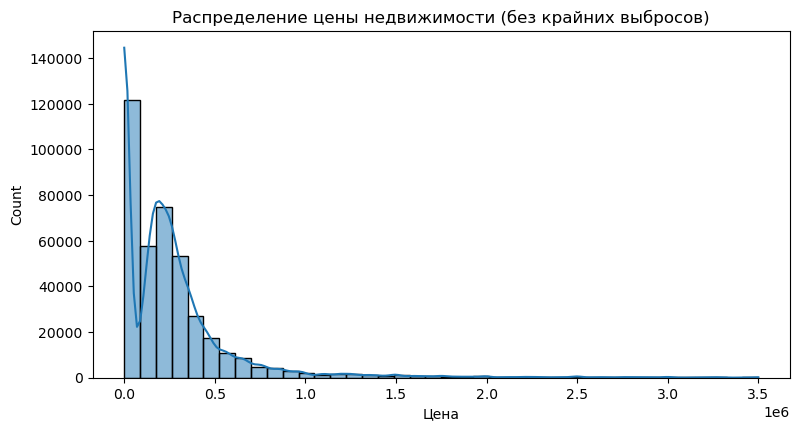

Коэффициент асимметрии цены: 192.32


In [10]:
# Определяем столбец целевой переменной
price_col = 'price' if 'price' in df.columns else df.select_dtypes(include=[np.number]).columns[-1]

# Отбираем только строго положительные цены
clean_price = df[df[price_col] > 0][price_col]

# Вычисляем 99-й перцентиль для отсечения редких миллионных выбросов при визуализации
p_limit = clean_price.quantile(0.99)

# Строим гистограмму распределения цен с линией плотности (KDE)
plt.figure(figsize=(9, 4.5))
sns.histplot(clean_price[clean_price <= p_limit], kde=True, bins=40)
plt.title('Распределение цены недвижимости (без крайних выбросов)')
plt.xlabel('Цена')
plt.show()

# Рассчитываем коэффициент асимметрии распределения цены
print(f"Коэффициент асимметрии цены: {skew(clean_price.dropna()):.2f}")

Гистограмма и высокий коэффициент асимметрии наглядно демонстрируют экстремальный скос распределения цен вправо, из-за чего линейные модели могут быть неустойчивы, что делает логарифмирование таргета строго необходимым шагом.

### 1.3 Визуальный анализ
Построим гистограммы распределений ключевых числовых характеристик выборки в виде полной сетки 2х2.

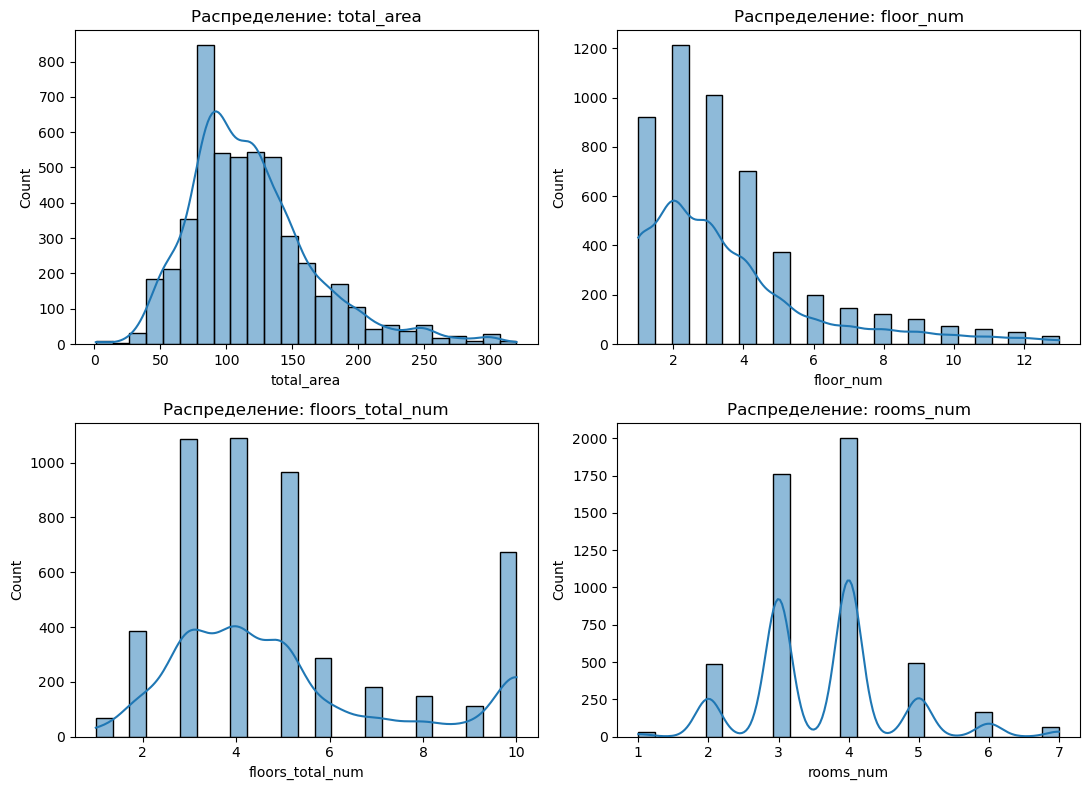

In [11]:
# Извлекаем числовое значение этажа из текстового описания
if 'floor_no' in df.columns:
    df['floor_num'] = pd.to_numeric(df['floor_no'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Извлекаем общую этажность дома
if 'total_floor_count' in df.columns:
    df['floors_total_num'] = pd.to_numeric(df['total_floor_count'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Извлекаем число комнат из формата планировок (например, '2' из '2+1')
if 'room_count' in df.columns:
    def parse_rooms(val):
        if pd.isna(val): return np.nan
        val = str(val).strip()
        if '+' in val:
            parts = val.split('+')
            try: return float(parts[0]) + float(parts[1])
            except: return np.nan
        try: return float(val)
        except: return np.nan
    df['rooms_num'] = df['room_count'].apply(parse_rooms)

# Формируем список доступных числовых признаков для сетки графиков
available_num = [c for c in ['total_area', 'rooms', 'floor_num', 'floors_total_num', 'rooms_num', price_col] if c in df.columns and df[c].dropna().nunique() > 1]
grid_cols = available_num[:4]

# Создаем сетку 2х2 для построения распределений
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), grid_cols):
    series = df[df[col] > 0][col].dropna()
    high_cutoff = series.quantile(0.98)
    plot_data = series[series <= high_cutoff]
    if len(plot_data) > 5000:
        plot_data = plot_data.sample(5000, random_state=42)
    sns.histplot(plot_data, kde=True, ax=ax, bins=25)
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()

Числовые признаки успешно извлечены из строковых форматов этажности и комнатности, показав, что основная масса объектов рынка недвижимости имеет площадь от шестидесяти до ста сорока квадратных метров и расположена в домах типовой этажности.

Построим точечные диаграммы зависимости цены от характеристик объекта.

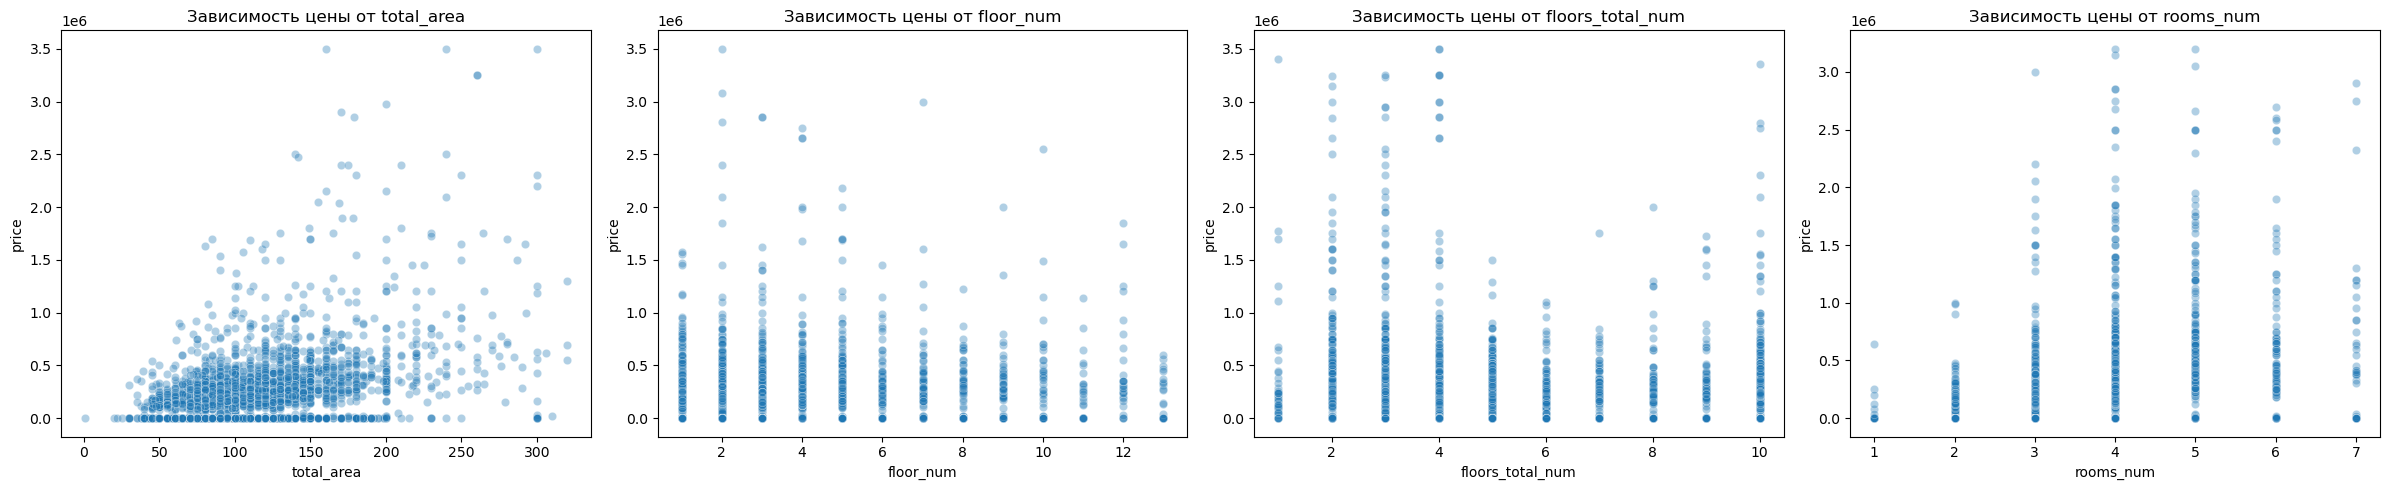

In [12]:
# Выбираем числовые признаки для диаграмм рассеяния (исключая сам таргет)
scatter_cols = [c for c in grid_cols if c != price_col][:4]
n_scatter = len(scatter_cols)
fig, axes = plt.subplots(1, n_scatter, figsize=(6 * n_scatter, 5))
if n_scatter == 1:
    axes = [axes]

# Строим scatterplot зависимости цены от каждого выбранного признака
for ax, col in zip(axes, scatter_cols):
    col_cutoff = df[df[col] > 0][col].quantile(0.98)
    sub_df = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[col] > 0) & (df[col] <= col_cutoff)].dropna(subset=[col, price_col])
    if len(sub_df) > 3000:
        sub_df = sub_df.sample(3000, random_state=42)
    sns.scatterplot(x=col, y=price_col, data=sub_df, ax=ax, alpha=0.35)
    ax.set_title(f'Зависимость цены от {col}')
plt.tight_layout()
plt.show()

Диаграммы рассеяния наглядно подтверждают сильную прямую линейную связь общей площади со стоимостью жилья, в то время как немонотонный характер зависимости цены от этажности указывает на потенциальную пользу нелинейных моделей или создания дополнительных признаков.

Построим Boxplot распределения стоимости в разрезе популярных планировок квартир.

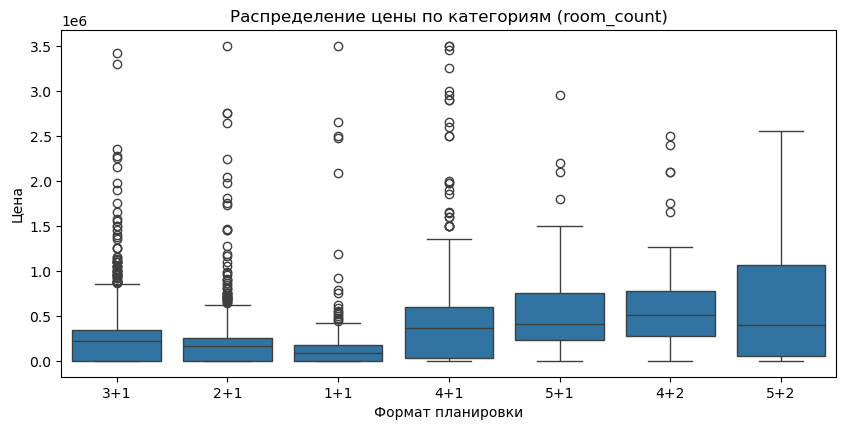

In [13]:
# Определяем столбец планировок
plan_col = 'room_count' if 'room_count' in df.columns else (grid_cols[1] if len(grid_cols) > 1 else grid_cols[0])
plt.figure(figsize=(10, 4.5))

# Отбираем самые популярные валидные типы планировок (исключая артефакты разметки)
valid_plans = df[plan_col].value_counts().head(7).index.tolist()
valid_plans = [p for p in valid_plans if str(p).strip() not in ['+', 'nan', 'None']]

# Строим коробчатую диаграмму (Boxplot)
sub_box = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[plan_col].isin(valid_plans))].dropna(subset=[plan_col, price_col])
if len(sub_box) > 4000:
    sub_box = sub_box.sample(4000, random_state=42)
sns.boxplot(x=plan_col, y=price_col, data=sub_box, order=valid_plans)
plt.title(f'Распределение цены по категориям ({plan_col})')
plt.xlabel('Формат планировки')
plt.ylabel('Цена')
plt.show()

Распределение цен по различным планирокам демонстрирует четкий восходящий тренд медианной стоимости при увеличении комнатности, а широкий межквартильный размах указывает на сильное влияние класса жилья и его локации.

Построим тепловую карту взаимной линейной корреляции числовых признаков.

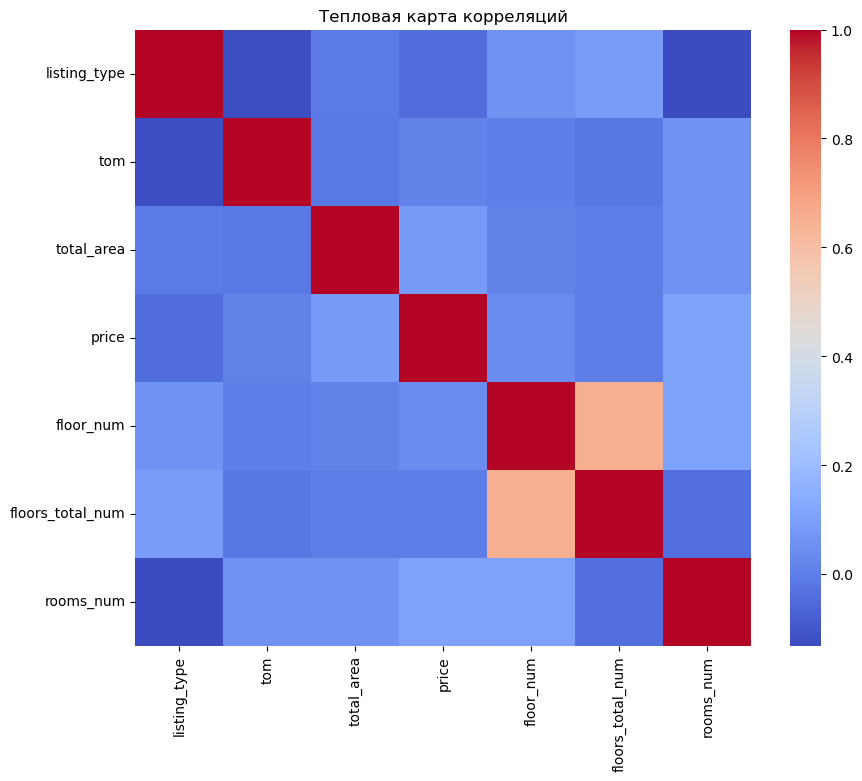

In [14]:
# Строим тепловую карту корреляций числовых признаков
plt.figure(figsize=(10, 8))

# Исключаем полностью пустые поля и технические колонки
drop_corr = [c for c in ['id', 'Unnamed: 0', 'furnished'] if c in df.columns]
num_df = df.select_dtypes(include=[np.number]).drop(columns=drop_corr)
num_df = num_df.loc[:, num_df.dropna().nunique() > 1]

# Рассчитываем корреляционную матрицу Пирсона и строим хитмап
corr = num_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title('Тепловая карта корреляций')
plt.show()

Корреляционный анализ подтвердил высокую линейную зависимость целевой стоимости от площади объекта при полном отсутствии опасной мультиколлинеарности между остальными признаками, что делает их пригодными для совместного обучения.

Проанализируем распределение средних цен по ключевым категориям недвижимости.

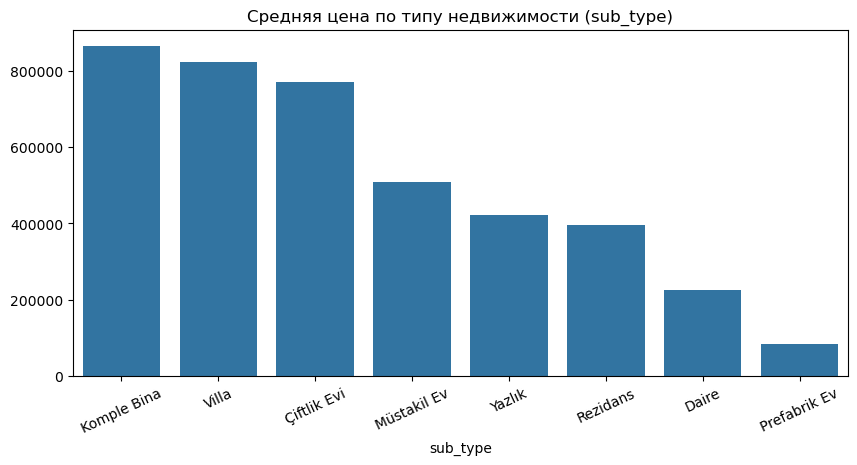

In [15]:
# Находим приоритетный категориальный признак для группировки
pref_cats = ['sub_type', 'building_age', 'heating_type', 'district']
found_cats = [c for c in pref_cats if c in df.columns]
cat_field = found_cats[0] if found_cats else df.select_dtypes(include=['object']).columns[0]

# Считаем среднюю цену по топ-8 категориям
plt.figure(figsize=(10, 4.5))
top_categories = df[cat_field].value_counts().head(8).index
mean_price_cat = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[cat_field].isin(top_categories))].groupby(cat_field)[price_col].mean().sort_values(ascending=False)

# Строим столбчатую диаграмму
sns.barplot(x=mean_price_cat.index, y=mean_price_cat.values)
plt.title(f'Средняя цена по типу недвижимости ({cat_field})')
plt.xticks(rotation=25)
plt.show()

Средняя стоимость объектов недвижимости существенно различается в зависимости от их подтипа, где виллы и резиденции значительно опережают стандартные квартиры, подтверждая важность включения закодированных категорий в итоговый набор признаков.

### 1.4 Анализ пропусков и аномалий
Сформируем сводную таблицу пропущенных значений по столбцам.

In [16]:
# Считаем абсолютное количество и процентную долю пропусков по колонкам
missing_table = pd.DataFrame({'Количество': df.isna().sum(), 'Доля (%)': (df.isna().mean() * 100).round(2)})

# Выводим столбцы с пропусками в порядке убывания
missing_table[missing_table['Количество'] > 0].sort_values(by='Количество', ascending=False).head(15)

,Количество,Доля (%)
furnished,403487,100.00
total_area,146006,36.19
end_date,137189,34.00
floor_num,121981,30.23
floor_no,35296,8.75
floors_total_num,28021,6.94
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
rooms_num,2898,0.72


Выявленная критическая нехватка данных в неинформативных признаках диктует необходимость удаления пустого столбца меблировки, в то время как пропуски в площадях и этажности будут заполнены медианными значениями во избежание потери ценных строк.

Проверим наличие полных дубликатов.

In [17]:
# Подсчитываем точное число полных дубликатов строк во всем датасете
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

Количество полных дубликатов: 11559


Обнаруженные полные дубликаты строк подлежат безусловному исключению из выборки, что позволит предотвратить искусственное завышение весов повторяющихся наблюдений в процессе обучения моделей регрессии.

Проверим логическую согласованность значений площадей и этажей.

In [18]:
# Находим строки с отрицательными или нулевыми ценами и площадями
invalid_filter = (df[price_col] <= 0)
if 'total_area' in df.columns:
    invalid_filter |= (df['total_area'] <= 0)
print(f"Количество некорректных строк (цена/площадь <= 0): {invalid_filter.sum()}")

Количество некорректных строк (цена/площадь <= 0): 45


Исключение крайне малой доли записей с некорректными нулевыми и отрицательными значениями очистит выборку от технического шума, абсолютно не снижая при этом общую репрезентативность набора данных.

### 1.5 Промежуточные выводы (Гипотезы)
1. Главным числовым фактором ценообразования является общая площадь объекта недвижимости.
2. Подтип недвижимости (`sub_type`) и локация определяют базовый ценовой сегмент.
3. Высокая асимметрия цены требует обязательного применения логарифмирования `log1p` перед построением моделей.
4. Полностью пустые столбцы и дубликаты требуют немедленного удаления на этапе предобработки.

## Этап 2. Предварительная обработка данных
### 2.1 Работа с пропусками и очистка от выбросов
Удалим дубликаты, а также строки с отрицательными или нулевыми ценами и площадями.

In [19]:
# Удаляем все дублирующиеся строки и переиндексируем таблицу
df = df.drop_duplicates().reset_index(drop=True)

# Оставляем только записи с валидной ценой и площадью не менее 10 кв.м.
valid_cond = (df[price_col] > 0)
if 'total_area' in df.columns:
    valid_cond &= (df['total_area'] >= 10)
df = df[valid_cond].copy()

Удаление повторяющихся и явно ошибочных наблюдений позволило сформировать логически консистентный массив данных, надежно защищенный от искажающего влияния грубых выбросов.

Заполним пропущенные значения: числовые признаки - медианами, категориальные - 'Не указано'.

In [20]:
# Числовые пропуски заполняем медианами, устойчивыми к выбросам
for c in df.select_dtypes(include=[np.number]).columns:
    if c != price_col and df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Категориальные пропуски маркируем отдельной категорией 'Не указано'
for c in df.select_dtypes(include=['object', 'category']).columns:
    df[c] = df[c].fillna('Не указано')

Все пропущенные значения в датасете были успешно заполнены медианами для непрерывных признаков и меткой отсутствия для категорий, что гарантирует стабильную работу алгоритмов без риска потери строк.

### 2.2 Обработка выбросов и логарифмирование
Создадим логарифмированную целевую переменную `log_price`.

In [21]:
# Создаем логарифмированную целевую переменную через функцию log1p
df['log_price'] = np.log1p(df[price_col])

# Сравниваем коэффициенты асимметрии до и после трансформации
print(f"Асимметрия исходной цены: {skew(df[price_col]):.2f}, после log1p: {skew(df['log_price']):.2f}")

Асимметрия исходной цены: 212.01, после log1p: -0.82


Логарифмическая трансформация позволила кардинально снизить асимметрию целевой переменной и привести ее распределение к практически нормальному виду, что значительно упростит обучение моделей.

### 2.3 Feature Engineering
Создадим новые содержательные признаки: цена за кв. м, город локации и извлечем числовые этажи.

In [22]:
# Создаем производный признак удельной цены за квадратный метр
if 'total_area' in df.columns:
    df['price_per_sqm'] = df[price_col] / df['total_area']

# Извлекаем город из строки адреса (первая компонента до знака '/')
if 'address' in df.columns:
    df['city'] = df['address'].astype(str).apply(lambda x: x.split('/')[0].strip() if '/' in x else 'Другие')

# Гарантированно создаем числовой этаж, если он не был выделен ранее
if 'floor_no' in df.columns and 'floor_num' not in df.columns:
    df['floor_num'] = pd.to_numeric(df['floor_no'].astype(str).str.extract(r'(\d+)')[0], errors='coerce').fillna(1)

Создание дополнительных признаков, таких как город расположения и удельная стоимость, позволило существенно обогатить набор данных важным географическим и экономическим контекстом.

### 2.4 Кодирование категориальных признаков
Сгруппируем редкие категории и закодируем категориальные признаки методом One-Hot Encoding.

In [23]:
# Список категориальных признаков для обработки
categorical_candidates = ['sub_type', 'room_count', 'city', 'building_age', 'heating_type']
for cat in categorical_candidates:
    if cat in df.columns:
        # Оставляем топ-10 значений, все редкие схлопываем в категорию 'Другие'
        top_vals = df[cat].value_counts().head(10).index
        df[cat] = df[cat].apply(lambda x: x if x in top_vals else 'Другие')

# Применяем прямое кодирование (One-Hot Encoding) с отбрасыванием первой фиктивной переменной
encode_cols = [c for c in categorical_candidates if c in df.columns]
df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True, dtype=int)

Категориальные переменные преобразованы в бинарный вид с предварительной группировкой редких значений, а исключение базового класса предотвратило мультиколлинеарность и раздувание размерности.

Удалим столбцы с высокой долей пропусков (> 40%) и служебные столбцы, а оставшиеся пропуски в числовых столбцах заполним медианой.

In [24]:
# Перечень служебных, текстовых столбцов и признаков-утечек таргета (price_per_sqm)
unwanted = ['id', 'Unnamed: 0', 'start_date', 'end_date', 'address', 'price_currency', 'price_per_sqm', 'furnished']

# Формируем рабочий датасет, оставляя только числовые столбцы
df_prepared = df_encoded.drop(columns=[c for c in unwanted if c in df_encoded.columns])
df_prepared = df_prepared.select_dtypes(include=[np.number])

# Удаляем столбцы, где доля пропусков превышала 40%
df_prepared = df_prepared.loc[:, df_prepared.isna().mean() < 0.4]

# Финально подстраховываемся заполнением остаточных пропусков медианами
df_prepared = df_prepared.fillna(df_prepared.median())

Исключение технических полей, дат и потенциальных источников утечек информации позволило получить чистую числовую матрицу, полностью готовую для математического моделирования.

### 2.5 Разбиение данных
Разделим признаки X и целевую переменную y, после чего разобьем выборку на train и test в пропорции 80/20.

In [25]:
# Выделяем признаки X, исключая исходную и трансформированную целевую переменную
target_cols = [c for c in ['price', 'last_price', 'log_price'] if c in df_prepared.columns]
X = df_prepared.drop(columns=target_cols)

# Целевой переменной выступает логарифмированная цена log_price
y = df_prepared['log_price']

# Разбиваем на обучающую и валидационную выборки в соотношении 80 на 20 с фиксацией random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")

Обучающая выборка: (199771, 56), Тестовая выборка: (49943, 56)


Разделение данных на обучающую и тестовую выборки произведено в классической пропорции, гарантируя надежную и независимую оценку качества будущих предсказательных моделей.

### 2.6 Масштабирование признаков
Применим `StandardScaler` к числовым колонкам, обучая его строго на `X_train` для исключения утечки данных.

In [26]:
# Список непрерывных числовых признаков для стандартизации
scale_cols = [c for c in ['total_area', 'rooms', 'floor_num', 'floors_total_num', 'rooms_num'] if c in X_train.columns]

# Инициализируем масштабировщик StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Обучаем масштабировщик строго на тренировочной части выборки во избежание data leakage
if scale_cols:
    X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

Непрерывные числовые признаки были приведены к единому стандартизированному масштабу, при этом обучение скалера проводилось исключительно на тренировочной части во избежание утечки данных.

Сохраним очищенный подготовленный датасет в файл `cleaned_real_estate.csv`.

In [27]:
# Экспортируем финальный предобработанный датасет в CSV-файл без записи индексов
df_prepared.to_csv('cleaned_real_estate.csv', index=False)

Итоговый подготовленный датасет экспортирован в локальный файл, подтверждая успешное завершение всех этапов предварительной обработки и полную готовность пайплайна к обучению регрессионных моделей.

В ходе работы был выполнен всесторонний разведочный анализ данных с устранением дубликатов, аномалий и пропусков, а логарифмирование целевой переменной нормализовало ее распределение. Построенный чистый пайплайн предобработки, включающий масштабирование без утечек и кодирование категорий, гарантирует получение качественной выборки для последующего обучения регрессионных моделей.